# 03 — Exploratory Data Analysis

Joins the cleaned viewing history to the TMDB metadata and establishes the baselines
and feature intuitions that the modelling work depends on.

**Input:** `data/interim/viewings.csv`, `data/interim/films_enriched.csv`
**Output:** `data/interim/modelling_base.csv` — one row per viewing, film metadata
attached, sorted chronologically

Targeted rather than exhaustive. Each section answers a question that changes a
downstream decision.


## 1. Join

`validate="many_to_one"` asserts the expected shape — many viewings to one film,
because of rewatches. A duplicate `film_key` in the enriched file would raise here
rather than silently multiplying rows.

`parse_dates` on the read because CSV does not preserve dtypes, and chronological
order is load-bearing for everything downstream.

Two viewings are expected to be unmatched: *World on a Wire* and *Twin Peaks: The
Return*, both television entries excluded in `02`.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

viewings = pd.read_csv("data/interim/viewings.csv", parse_dates=["watched_date", "logged_date"])
films    = pd.read_csv("data/interim/films_enriched.csv")

df = viewings.merge(films, on="film_key", how="left", validate="many_to_one")

print(f"viewings: {len(viewings)}  films: {len(films)}  joined: {len(df)}")
print(f"unmatched viewings: {df['tmdb_id'].isna().sum()}")
print()
print(df[df["tmdb_id"].isna()][["film_title_x", "film_year_x", "watched_date"]].to_string(index=False))

viewings: 1194  films: 1174  joined: 1194
unmatched viewings: 2

          film_title_x  film_year_x watched_date
       World on a Wire         1973   2024-03-10
Twin Peaks: The Return         2017   2025-11-10


Keeping the `_x` (Letterboxd) title and year as canonical identity. TMDB's
equivalents remain available as `tmdb_title` and `release_date`, so nothing is lost,
and this avoids confusion where the two sources disagree by a year.


In [2]:
df = df[df["tmdb_id"].notna()].copy()

df = df.drop(columns=["film_title_y", "film_year_y"]).rename(
    columns={"film_title_x": "film_title", "film_year_x": "film_year"})

print(f"{len(df)} viewings, {df['film_key'].nunique()} unique films, {df.shape[1]} columns")
print([c for c in df.columns if c.endswith(("_x", "_y"))] or "no suffixed columns")

1192 viewings, 1174 unique films, 36 columns
no suffixed columns


## 2. The target variable

The interquartile range is the number to hold onto: half of all ratings fall between
3.0 and 4.0. A model that always guesses 3.5 is already within half a star most of
the time, so there is less room to demonstrate skill than the 0.5–5.0 range suggests.

The distribution is left-skewed with a thin tail — 42 films below 2.0 against 559 at
3.5 or 4.0. Those 42 will be predicted poorly by every model built here.


In [3]:
print(df["rating"].describe().round(3))
print()
print(df["rating"].value_counts().sort_index())

count    1192.000
mean        3.561
std         0.883
min         0.500
25%         3.000
50%         3.500
75%         4.000
max         5.000
Name: rating, dtype: float64

rating
0.5      5
1.0     11
1.5     26
2.0     49
2.5    118
3.0    182
3.5    242
4.0    311
4.5    156
5.0     92
Name: count, dtype: int64


## 3. Model 0 — the baseline

Chronological 80/20 split. Predicting the training median for every test film gives
the cost of knowing nothing, and every later model is measured against it.

The split lands on 3 Oct 2024 and yields 239 test films from the sparsest period of
the history. This is the constraint behind the planned bootstrap confidence intervals
— at n=239, a difference of 0.02 MAE between two models is not distinguishable from
noise.


In [4]:
df_sorted = df.sort_values("watched_date").reset_index(drop=True)
split_idx = int(len(df_sorted) * 0.8)

train = df_sorted[:split_idx]
test  = df_sorted[split_idx:]

baseline = train["rating"].median()
mae = (test["rating"] - baseline).abs().mean()

print(f"split at {test['watched_date'].min().date()}")
print(f"train {len(train)}  test {len(test)}")
print(f"baseline (train median) = {baseline}")
print(f"Model 0 test MAE = {mae:.3f}")


split at 2024-10-03
train 953  test 239
baseline (train median) = 3.5
Model 0 test MAE = 0.682


## 4. Rating trend over time

Mean rating falls from 3.71 (2022) to 3.42 (2024), then partially recovers. A ~0.29
star movement across the middle of the history.

**This is a trend, not an explanation.** Harsher standards, a shift in what was
watched, or both, are all consistent with the data, and it cannot distinguish between
them.

Two consequences for modelling. It justifies the chronological split — a random split
would scatter these years across train and test and hide the effect entirely. And it
means part of any improvement Models 2–4 show may be them tracking this trend rather
than learning taste, which is why a recency-weighted running mean belongs in the
history features: so the trend is captured by an identifiable feature rather than
smeared across genre averages.

Years with fewer than 30 films are excluded, which drops 2021 (5 films, part-month
only). **2026 is also a partial year** — it is included because volume is sufficient,
but its count should not be compared with complete years.


In [5]:
yearly = df.groupby(df["watched_date"].dt.year)["rating"].agg(["count", "mean"]).round(3)
print(yearly)

              count   mean
watched_date              
2021              5  3.700
2022            388  3.707
2023            340  3.549
2024            260  3.417
2025            115  3.430
2026             84  3.548


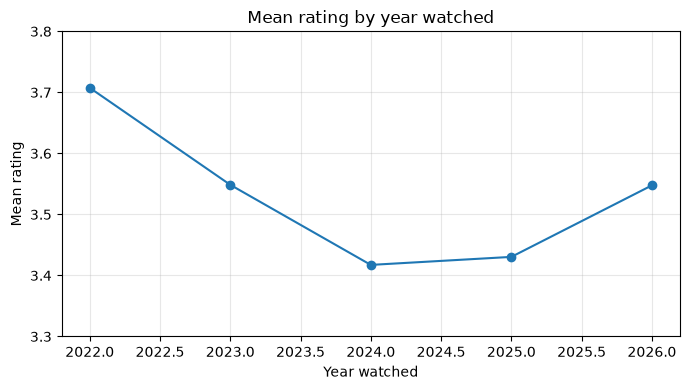

In [6]:
yearly = df.groupby(df["watched_date"].dt.year)["rating"].agg(["count", "mean"])
yearly = yearly[yearly["count"] >= 30]        # drops 2021 (5 films, part-month only)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(yearly.index, yearly["mean"], marker="o")
ax.set_title("Mean rating by year watched")
ax.set_xlabel("Year watched")
ax.set_ylabel("Mean rating")
ax.set_ylim(3.3, 3.8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Personal rating vs crowd score

The central comparison of the project.


In [7]:
df["tmdb_rating_5"] = df["vote_average"] / 2
df["divergence"] = df["rating"] - df["tmdb_rating_5"]

print(f"correlation: {df['rating'].corr(df['tmdb_rating_5']):.3f}")
print(f"mean divergence: {df['divergence'].mean():+.3f}")
print(f"MAE if you just used TMDB's score: {df['divergence'].abs().mean():.3f}")

correlation: 0.424
mean divergence: -0.016
MAE if you just used TMDB's score: 0.633


Three findings:

**Correlation 0.42.** Moderate — roughly 18% of the variance in personal ratings is
explained by the crowd score. Substantial room remains for personal signal.

**Mean divergence −0.016.** Almost exactly as generous as TMDB's users on average.
The story is not "harsher critic" but "agrees on average, disagrees film by film" —
the disagreement is not systematic.

**MAE 0.633 using the raw crowd score.** Beats the 0.682 baseline by 0.049 with no
model fitted at all. Note this is computed across all 1,192 films, not the test set,
so it is not directly comparable — Model 1 proper will be fitted on train and scored
on test. It sets the expectation that crowd score is informative but weakly so.


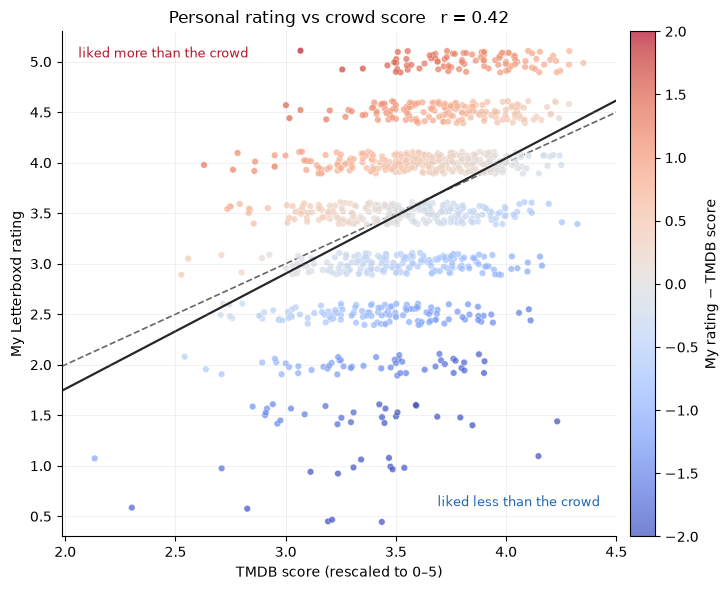

In [8]:
rng = np.random.default_rng(0)
jitter = rng.uniform(-0.11, 0.11, len(df))

fig, ax = plt.subplots(figsize=(7.5, 6))

sc = ax.scatter(df["tmdb_rating_5"], df["rating"] + jitter,
                c=df["divergence"], cmap="coolwarm",
                vmin=-2, vmax=2, alpha=0.7, s=22,
                edgecolors="white", linewidths=0.3)

lims = [df["tmdb_rating_5"].min() - 0.15, df["tmdb_rating_5"].max() + 0.15]
ax.plot(lims, lims, "--", color="0.4", linewidth=1.2, zorder=0)

m, b = np.polyfit(df["tmdb_rating_5"], df["rating"], 1)
xs = np.array(lims)
ax.plot(xs, m * xs + b, color="0.15", linewidth=1.6, zorder=1)

ax.set_xlim(lims)
ax.set_ylim(0.3, 5.3)
ax.set_xlabel("TMDB score (rescaled to 0–5)")
ax.set_ylabel("My Letterboxd rating")
ax.set_title(f"Personal rating vs crowd score   r = {df['rating'].corr(df['tmdb_rating_5']):.2f}")
ax.set_yticks(np.arange(0.5, 5.5, 0.5))
ax.grid(alpha=0.25, linewidth=0.5)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)

cb = fig.colorbar(sc, ax=ax, pad=0.02)
cb.set_label("My rating − TMDB score")

ax.text(0.03, 0.97, "liked more than the crowd", transform=ax.transAxes,
        va="top", fontsize=9, color="#b2182b")
ax.text(0.97, 0.06, "liked less than the crowd", transform=ax.transAxes,
        ha="right", fontsize=9, color="#2166ac")

plt.tight_layout()
plt.show()

The jitter is **cosmetic only**, applied at plot time; `rating` itself is
unmodified. Without it the discrete half-stars stripe into ten flat lines.

The solid line is the fitted relationship, the dashed line is perfect agreement. The
gap between them is the point: the fit is far flatter than the diagonal, meaning
personal ratings vary much more than crowd scores do. That flatness is the visual
argument for why the crowd score alone cannot predict this viewer — and therefore why
the rest of the project exists.


## 6. Review length vs rating — a negative result

Hypothesis: more is written about films felt strongly about in either direction,
giving a U-shape, which would make `review_words` a useful feature.

**It does not hold.** Medians sit between 50 and 90 words across all ten rating
levels, while each level individually spans zero to 250+. Within-group variation
dwarfs between-group variation.

The only defensible structure is a mild rise from 3.5 (69 words) through 5.0 (91),
supported by large samples. The low end does not mirror it, so this is a weak upward
trend rather than a U.

A line plot of the medians was tried first and **discarded as misleading** — it made
sampling noise in the small bins (n=5 at 0.5, n=11 at 1.0) look like structure. The
boxplot shows the spread and sample sizes, which is the honest picture.

Conclusion: keep `review_words` as a feature since it costs nothing, but expect it low
in any importance ranking.


In [9]:
by_rating = df.groupby("rating")["review_words"].agg(["count", "median"])
print(by_rating)


        count  median
rating               
0.5         5    66.0
1.0        11    86.0
1.5        26    79.5
2.0        49    51.0
2.5       118    82.0
3.0       182    82.0
3.5       242    69.5
4.0       311    76.0
4.5       156    86.0
5.0        92    90.5


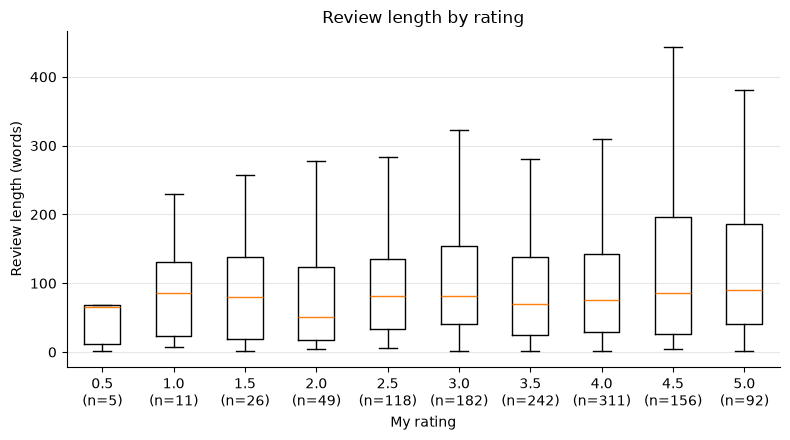

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))

groups = [df.loc[df["rating"] == r, "review_words"].values for r in sorted(df["rating"].unique())]
labels = [f"{r}\n(n={len(g)})" for r, g in zip(sorted(df["rating"].unique()), groups)]

ax.boxplot(groups, tick_labels=labels, showfliers=False)
ax.set_xlabel("My rating")
ax.set_ylabel("Review length (words)")
ax.set_title("Review length by rating")
ax.grid(alpha=0.3, axis="y")
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

## 7. Genre

Feeds the historical-preference features directly, so this matters more than the
previous two sections.


In [11]:
genres = df.assign(genre=df["genres"].str.split("|")).explode("genre")
genres = genres[genres["genre"].notna() & (genres["genre"] != "")]

by_genre = (genres.groupby("genre")["rating"]
            .agg(["count", "mean"])
            .query("count >= 20")
            .sort_values("mean", ascending=False)
            .round(3))
print(by_genre)

                 count   mean
genre                        
War                 30  3.750
Crime              195  3.690
Drama              779  3.681
Mystery            155  3.597
History             70  3.579
Romance            195  3.546
Animation           42  3.536
Fantasy             98  3.500
Thriller           306  3.489
Family              40  3.425
Science Fiction    163  3.420
Horror             141  3.408
Adventure          145  3.369
Music               22  3.364
Comedy             304  3.327
Action             156  3.276


War (3.75) to Action (3.28) — a 0.47 star spread against an overall standard
deviation of 0.88. The ordering is coherent: War, Crime, Drama, Mystery at the top;
Comedy, Action, Adventure at the bottom.

Two cautions. **Genres overlap heavily** — Drama alone covers 779 of 1,192 films, so
these means are not independent and one underlying preference may be expressing itself
through several correlated labels. **Small samples at the top** — War is 30 films,
Music 22, so the gap between the leading genres is not distinguishable.

The large-sample figures do hold up: Comedy at 3.33 (n=304), Action at 3.28 (n=156),
Drama at 3.68 (n=779).

Encouraging for the history features: genre carries real signal and, unlike director,
densifies quickly — around 19 labels means dozens of films per genre within the first
year.


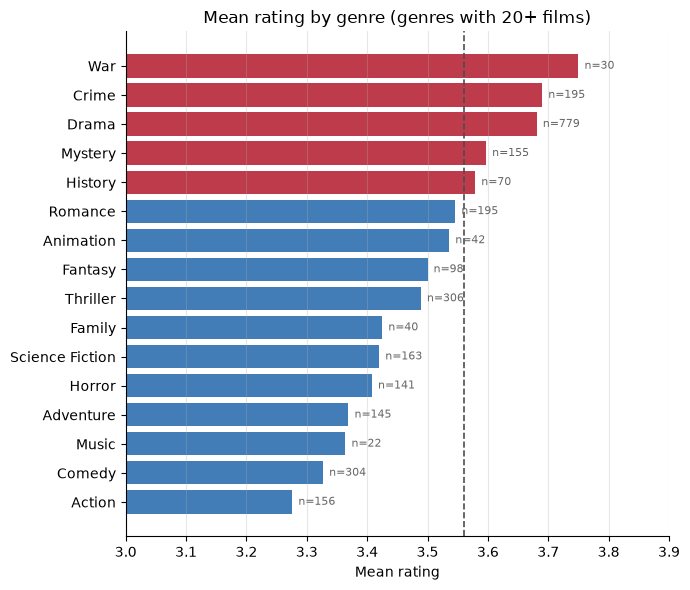

In [12]:
fig, ax = plt.subplots(figsize=(7, 6))
order = by_genre.sort_values("mean")
colors = ["#b2182b" if m > df["rating"].mean() else "#2166ac" for m in order["mean"]]

ax.barh(order.index, order["mean"], color=colors, alpha=0.85)
ax.axvline(df["rating"].mean(), color="0.3", linestyle="--", linewidth=1.2)
ax.set_xlim(3.0, 3.9)
ax.set_xlabel("Mean rating")
ax.set_title("Mean rating by genre (genres with 20+ films)")
for i, (n, m) in enumerate(zip(order["count"], order["mean"])):
    ax.text(m + 0.01, i, f"n={n}", va="center", fontsize=8, color="0.4")
ax.grid(alpha=0.3, axis="x")
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

## 8. Sparsity of person-level features

Decides whether director and cinematographer history features are viable at all.


In [13]:
for col in ["director", "cinematographer"]:
    seen = set(train[col].dropna())
    coverage = test[col].isin(seen).mean()
    print(f"{col:16s} {coverage:5.1%} of test films have a prior film in train")

print()
print("films per director (train):")
print(train["director"].value_counts().describe().round(2))
print()
print(f"directors seen once only: {(train['director'].value_counts() == 1).sum()} "
      f"of {train['director'].nunique()}")


director         58.2% of test films have a prior film in train
cinematographer  52.3% of test films have a prior film in train

films per director (train):
count    484.00
mean       1.97
std        1.78
min        1.00
25%        1.00
50%        1.00
75%        2.00
max       13.00
Name: count, dtype: float64

directors seen once only: 281 of 484


**Coverage is workable, depth is not.** 58% of test films have a director seen
before in training, and 52% for cinematographer — well above the ~15% that would have
made these features pointless.

But the median director appears **once**, and 281 of 484 directors appear exactly
once. So for much of that 58%, "historical mean rating for this director" is a mean
over a single film — that film's rating with extra steps, and noisy enough to hurt as
often as help.

This makes the `*_n_prior` companion columns essential rather than optional. A
director mean over one film and one over thirteen are different kinds of evidence, and
without the count the model cannot distinguish them.

Expect director features to show moderate importance concentrated in the handful of
directors seen five or more times. That is a finding about the limits of
personalisation at n=1,192, not a failure.


## 9. Save

Saving the **sorted** frame: chronological order is load-bearing downstream, and
sorting once here means `04` does not have to remember to.


In [14]:
OUT = Path("data/interim")
df_sorted.to_csv(OUT / "modelling_base.csv", index=False)
print(f"saved {len(df_sorted)} rows, {df_sorted.shape[1]} columns")

saved 1192 rows, 36 columns


---

## Summary of findings

| Finding | Consequence |
|---|---|
| Model 0 (train median) test MAE **0.682** | The number every model must beat |
| Half of all ratings fall in 3.0–4.0 | Limited room to demonstrate skill |
| Mean rating trends down 3.71 → 3.42 → 3.55 | Justifies chronological split; needs an explicit recency feature |
| Correlation with crowd score **0.42** | Real personal signal exists beyond consensus |
| Mean divergence **−0.016** | Agrees on average, disagrees film by film |
| Raw crowd score MAE **0.633** (all films) | Crowd is informative but weakly so |
| Review length ~flat across ratings | `review_words` is a weak feature — negative result |
| Genre spread 3.28–3.75 | Genre history features are worth building |
| Director coverage 58%, median 1 film | Viable, but `*_n_prior` counts are essential |

**Next:** `04_models.ipynb` — Models 0 and 1, then the feature blocks.
